# TPOSE24 validation vs OSCAR (surface currents)

OSCAR daily 0.25° surface currents (`u`, `v`, ~15 m; PODAAC `OSCAR_L4_OC_FINAL_V2.0`) are compared to the model surface velocity (`UVEL`, `VVEL`, top level ≈ 0.5 m — note the small depth mismatch).  The model is daily-averaged, matched to OSCAR on common calendar days, and regridded onto the OSCAR grid.

**1-D**: equatorial zonal (U) and meridional (V) surface current vs longitude (the SEC / cold-tongue surface signature); surface-speed RMSE time series; meridional profiles of U and V at the central longitude.

**2-D**: maps of time-mean zonal current (U) and meridional current (V), and of the U bias and V bias (model − OSCAR) for each run.

In [1]:
# ════════════════════════════════════════════════════════════════════
#  MODEL RUNS TO VALIDATE
#  Each entry is (label_for_figures, run_directory).
#  Add or remove entries here — every figure below updates its number
#  of lines / panels automatically.  Runs whose grid / ref_date / delta_t
#  differ from the TPOSE24 default (e.g. the TPOSE6 parent) supply the
#  extra open_mdsdataset kwargs via LOAD_KWARGS, keyed by run_directory.
# ════════════════════════════════════════════════════════════════════
MODELS = [
    ('Ri7', '/data/SO3/edavenport/tpose24/oct2012_3mo_dt300_AB3'),
    ('Ri3', '/data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month_Ri3'),
    ('Ri5', '/data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month_Ri5'),
    ('TPOSE6', '/data/SO3/edavenport/tpose6/diags/sep2012/run_iter14'),
]

# Non-default loader kwargs per run_directory (TPOSE24 runs use the defaults:
# grid_dir == run_dir, ref_date 2012-10-01, delta_t 300).
LOAD_KWARGS = {
    '/data/SO3/edavenport/tpose6/diags/sep2012/run_iter14': dict(
        grid_dir='/data/SO6/TPOSE_diags/tpose6/grid_6',
        ref_date='2012-09-01', delta_t=1200),
}

OUTDIR    = 'OSCAR_comparison'
OSCAR_DIR = '/data/SO3/edavenport/tpose24/oscar'   # OSCAR_L4_OC_FINAL_V2.0 daily granules, region-subset

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmocean.cm as cmo

import obs_validation_utils as u

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11})
os.makedirs(OUTDIR, exist_ok=True)
print(f'{len(MODELS)} model run(s):', [m[0] for m in MODELS])
print('Figures ->', OUTDIR)


4 model run(s): ['Ri7', 'Ri3', 'Ri5', 'TPOSE6']
Figures -> OSCAR_comparison


In [3]:
# ── OSCAR loader ─────────────────────────────────────────────────────
# OSCAR_L4_OC_FINAL_V2.0 daily granules (PODAAC), region-subset to the
# TPOSE24 box by oscar_download/.  Plain netCDF with dims
# (time, longitude, latitude); u, v are total surface currents (ug, vg
# are the geostrophic components, not used here).
import glob, re

def load_oscar(oscar_dir, t0, t1):
    """Load daily OSCAR granules overlapping [t0, t1] -> Dataset(u, v) on a
    (time, latitude, longitude) grid.  Returns None if nothing overlaps.

    The granule date is parsed from the filename so the time axis is a plain
    datetime64 that matches the model daily-mean axis (the files carry a
    non-standard 'julian' calendar that xarray would otherwise read as
    cftime and refuse to align with the model's datetime64 axis)."""
    files = sorted(glob.glob(os.path.join(oscar_dir, 'oscar_currents_final_*.nc')))
    if not files:
        return None
    frames = []
    for f in files:
        date = pd.Timestamp(re.search(r'(\d{8})', os.path.basename(f)).group(1))
        d = xr.open_dataset(f)[['u', 'v']]
        if 'time' in d.dims:
            d = d.isel(time=0, drop=True)
        d = d.assign_coords(time=date).expand_dims('time')
        frames.append(d)
    ds = xr.concat(frames, dim='time').sortby('time')
    ds = ds.transpose('time', 'latitude', 'longitude')
    ds = u.to_0360(ds)
    sel = ds.sel(time=slice(t0, t1))
    return sel if sel.time.size else None

In [4]:
# ── Load every model surface velocity; match to OSCAR days ───────────
# UVEL lives on (XG, YC), VVEL on (XC, YG); each is regridded from its
# own staggered coordinate onto the OSCAR centre grid.
results = {}
obs_u = obs_v = None
have_oscar = True

for i, (label, run_dir) in enumerate(MODELS):
    print(f'[{label}] loading {run_dir}')
    ds   = u.load_tpose24(run_dir, prefix=['diag_state'],
                          **LOAD_KWARGS.get(run_dir, {}))
    uvel = ds.UVEL.isel(Z=0).where(ds.UVEL.isel(Z=0) != 0)
    vvel = ds.VVEL.isel(Z=0).where(ds.VVEL.isel(Z=0) != 0)
    ud   = u.daily_mean(uvel)
    vd   = u.daily_mean(vvel)

    if obs_u is None:
        dom = u.model_domain(ds)
        t0  = str(ud.time.values[0])[:10]
        t1  = str(ud.time.values[-1])[:10]
        oscar = load_oscar(OSCAR_DIR, t0, t1)
        if oscar is None:
            have_oscar = False
            print('   No OSCAR granules overlap the run period '
                  f'({t0} – {t1}); skipping execution.')
            break
        oscar = u.subset_domain(oscar, *dom).compute()
        obs_lon = oscar.longitude; obs_lat = oscar.latitude

    # select model daily means on the OSCAR daily times (both floored to
    # day resolution so the datetime64 axes align exactly)
    def match_days(daily, otime):
        d = daily.assign_coords(time=daily.time.dt.floor('D'))
        return d.sel(time=otime)

    um = u.regrid_model_to_obs(match_days(ud, oscar.time), obs_lon, obs_lat,
                               x='XG', y='YC').compute()
    vm = u.regrid_model_to_obs(match_days(vd, oscar.time), obs_lon, obs_lat,
                               x='XC', y='YG').compute()

    if obs_u is None:
        obs_u = oscar.u; obs_v = oscar.v
        lat = obs_u.latitude.values; lon = obs_u.longitude.values
        time = obs_u.time.values

    uo = obs_u.values; vo = obs_v.values
    results[label] = dict(
        u_mean  = np.nanmean(um.values, axis=0),
        v_mean  = np.nanmean(vm.values, axis=0),
        u_bias  = np.nanmean(um.values - uo, axis=0),
        v_bias  = np.nanmean(vm.values - vo, axis=0),
        spd_rmse_t = u.weighted_spatial_rmse(
            np.hypot(um.values, vm.values), np.hypot(uo, vo), lat),
    )

if have_oscar:
    obs_u_mean = np.nanmean(obs_u.values, axis=0)
    obs_v_mean = np.nanmean(obs_v.values, axis=0)
    print('Aligned OSCAR days:', len(time))

[Ri7] loading /data/SO3/edavenport/tpose24/oct2012_3mo_dt300_AB3


[Ri3] loading /data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month_Ri3


[Ri5] loading /data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month_Ri5


[TPOSE6] loading /data/SO3/edavenport/tpose6/diags/sep2012/run_iter14


Aligned OSCAR days: 91


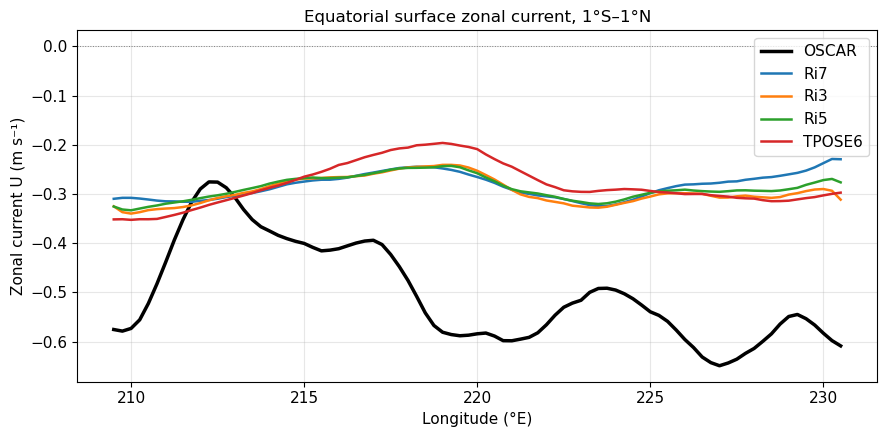

In [5]:
# ── 1-D: equatorial zonal surface current vs longitude (|lat|<1°) ────
assert have_oscar, 'No overlapping OSCAR data — see note at top of notebook.'

band = np.abs(lat) <= 1.0
w = np.cos(np.deg2rad(lat[band]))[:, None]
def band_mean(a2d):
    a = a2d[band, :]
    return np.nansum(a * w, axis=0) / np.nansum(w * np.isfinite(a), axis=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(lon, band_mean(obs_u_mean), color='k', lw=2.5, label='OSCAR')
for i, (label, _) in enumerate(MODELS):
    ax.plot(lon, band_mean(results[label]['u_mean']),
            color=u.model_color(i), lw=1.8, label=label)
ax.axhline(0, color='gray', lw=0.7, ls=':')
ax.set_xlabel('Longitude (°E)'); ax.set_ylabel('Zonal current U (m s⁻¹)')
ax.set_title('Equatorial surface zonal current, 1°S–1°N')
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
fig.savefig(f'{OUTDIR}/oscar_1d_equatorial_U.png', dpi=150,
            bbox_inches='tight')
plt.show()


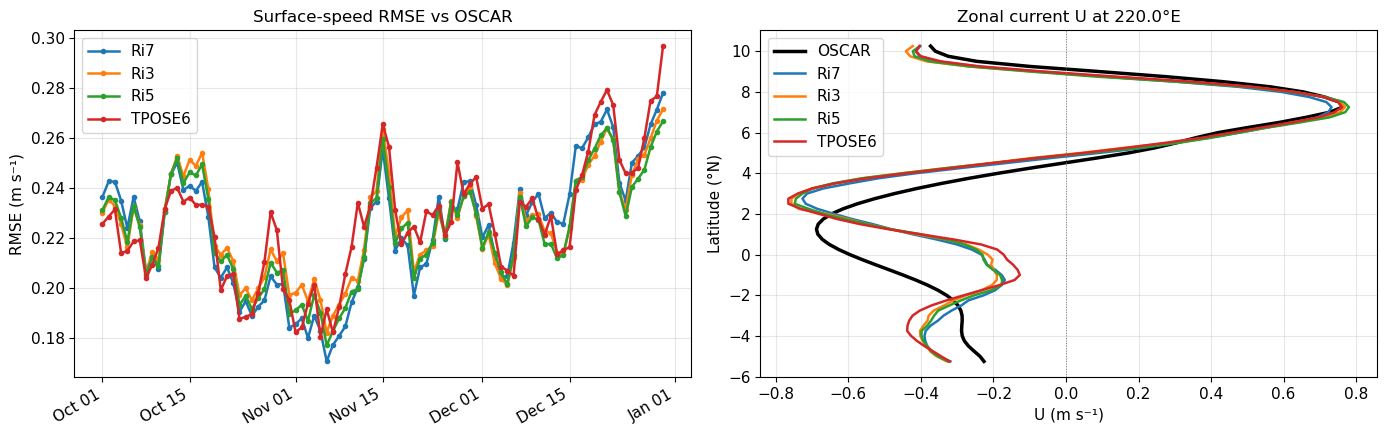

In [6]:
# ── 1-D: surface-speed RMSE time series + meridional U profile ───────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
tt = pd.to_datetime(time)
for i, (label, _) in enumerate(MODELS):
    axes[0].plot(tt, results[label]['spd_rmse_t'], color=u.model_color(i),
                 lw=1.8, marker='o', ms=3, label=label)
axes[0].set_title('Surface-speed RMSE vs OSCAR')
axes[0].set_ylabel('RMSE (m s⁻¹)'); axes[0].grid(alpha=0.3); axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

ic = len(lon) // 2
axes[1].plot(np.nanmean(obs_u.values, axis=0)[:, ic], lat, color='k',
             lw=2.5, label='OSCAR')
for i, (label, _) in enumerate(MODELS):
    axes[1].plot(results[label]['u_mean'][:, ic], lat,
                 color=u.model_color(i), lw=1.8, label=label)
axes[1].axvline(0, color='gray', lw=0.7, ls=':')
axes[1].set_title(f'Zonal current U at {lon[ic]:.1f}°E')
axes[1].set_xlabel('U (m s⁻¹)'); axes[1].set_ylabel('Latitude (°N)')
axes[1].grid(alpha=0.3); axes[1].legend()
fig.tight_layout()
fig.savefig(f'{OUTDIR}/oscar_1d_speed_rmse_profile.png', dpi=150,
            bbox_inches='tight')
plt.show()


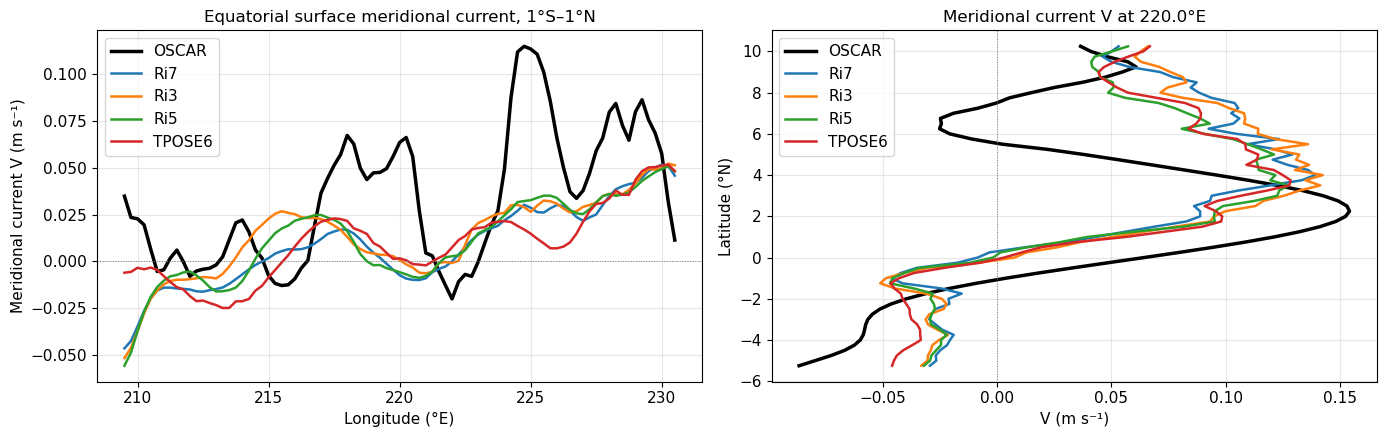

In [7]:
# ── 1-D: equatorial meridional current vs longitude + V profile ──────
# V counterparts of the two zonal-current 1-D panels above.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(lon, band_mean(obs_v_mean), color='k', lw=2.5, label='OSCAR')
for i, (label, _) in enumerate(MODELS):
    axes[0].plot(lon, band_mean(results[label]['v_mean']),
                 color=u.model_color(i), lw=1.8, label=label)
axes[0].axhline(0, color='gray', lw=0.7, ls=':')
axes[0].set_xlabel('Longitude (°E)')
axes[0].set_ylabel('Meridional current V (m s⁻¹)')
axes[0].set_title('Equatorial surface meridional current, 1°S–1°N')
axes[0].grid(alpha=0.3); axes[0].legend()

ic = len(lon) // 2
axes[1].plot(obs_v_mean[:, ic], lat, color='k', lw=2.5, label='OSCAR')
for i, (label, _) in enumerate(MODELS):
    axes[1].plot(results[label]['v_mean'][:, ic], lat,
                 color=u.model_color(i), lw=1.8, label=label)
axes[1].axvline(0, color='gray', lw=0.7, ls=':')
axes[1].set_title(f'Meridional current V at {lon[ic]:.1f}°E')
axes[1].set_xlabel('V (m s⁻¹)'); axes[1].set_ylabel('Latitude (°N)')
axes[1].grid(alpha=0.3); axes[1].legend()
fig.tight_layout()
fig.savefig(f'{OUTDIR}/oscar_1d_equatorial_V_profile.png', dpi=150,
            bbox_inches='tight')
plt.show()


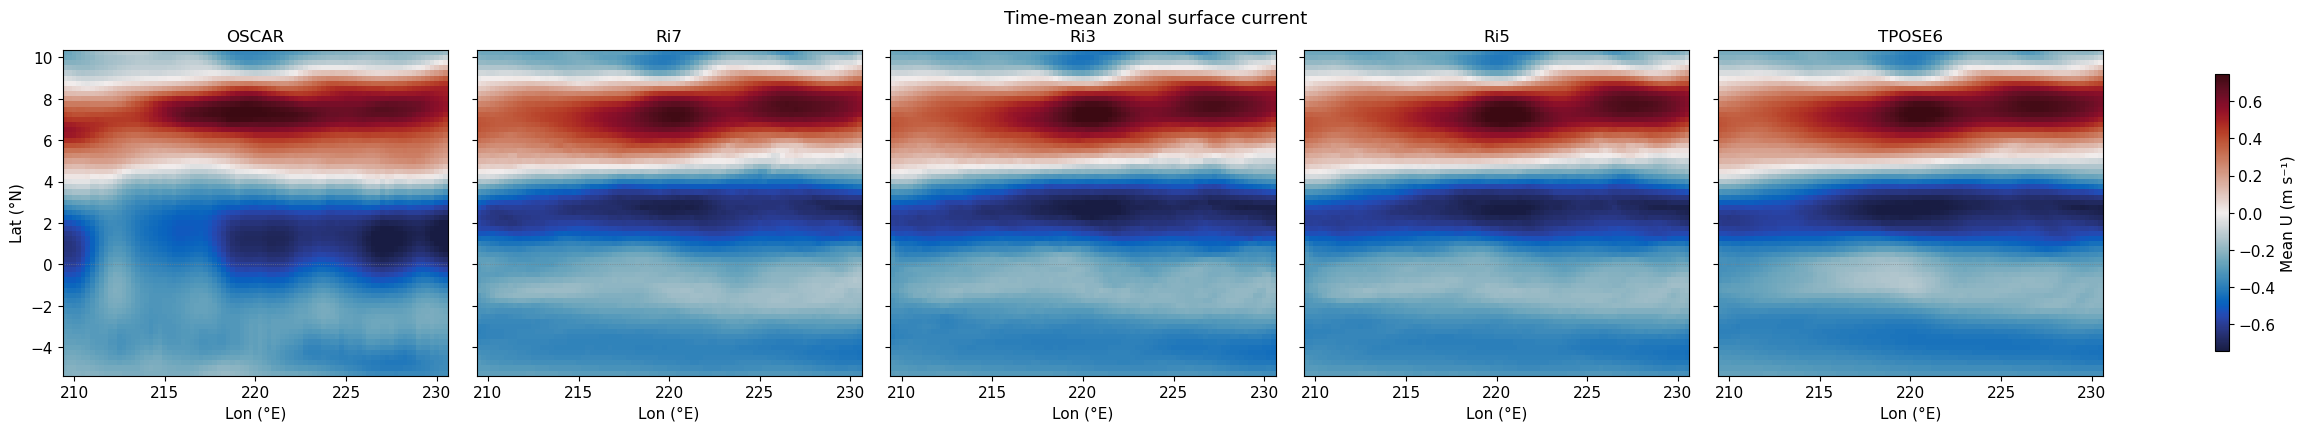

In [8]:
# ── 2-D: time-mean zonal current U (OSCAR + each model) ──────────────
n = len(MODELS) + 1
allv = [obs_u_mean] + [results[l]['u_mean'] for l, _ in MODELS]
vmax = np.nanmax([np.nanpercentile(np.abs(a), 99) for a in allv])
fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4), sharex=True,
                         sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
im = axes[0].pcolormesh(lon, lat, obs_u_mean, cmap=cmo.balance,
                        vmin=-vmax, vmax=vmax, shading='auto')
axes[0].set_title('OSCAR')
for i, (label, _) in enumerate(MODELS):
    axes[i + 1].pcolormesh(lon, lat, results[label]['u_mean'],
                           cmap=cmo.balance, vmin=-vmax, vmax=vmax,
                           shading='auto')
    axes[i + 1].set_title(label)
for ax in axes:
    ax.axhline(0, color='gray', lw=0.5, ls=':'); ax.set_xlabel('Lon (°E)')
axes[0].set_ylabel('Lat (°N)')
fig.colorbar(im, ax=axes, label='Mean U (m s⁻¹)', shrink=0.85)
fig.suptitle('Time-mean zonal surface current', y=1.04)
fig.savefig(f'{OUTDIR}/oscar_2d_mean_U.png', dpi=150, bbox_inches='tight')
plt.show()


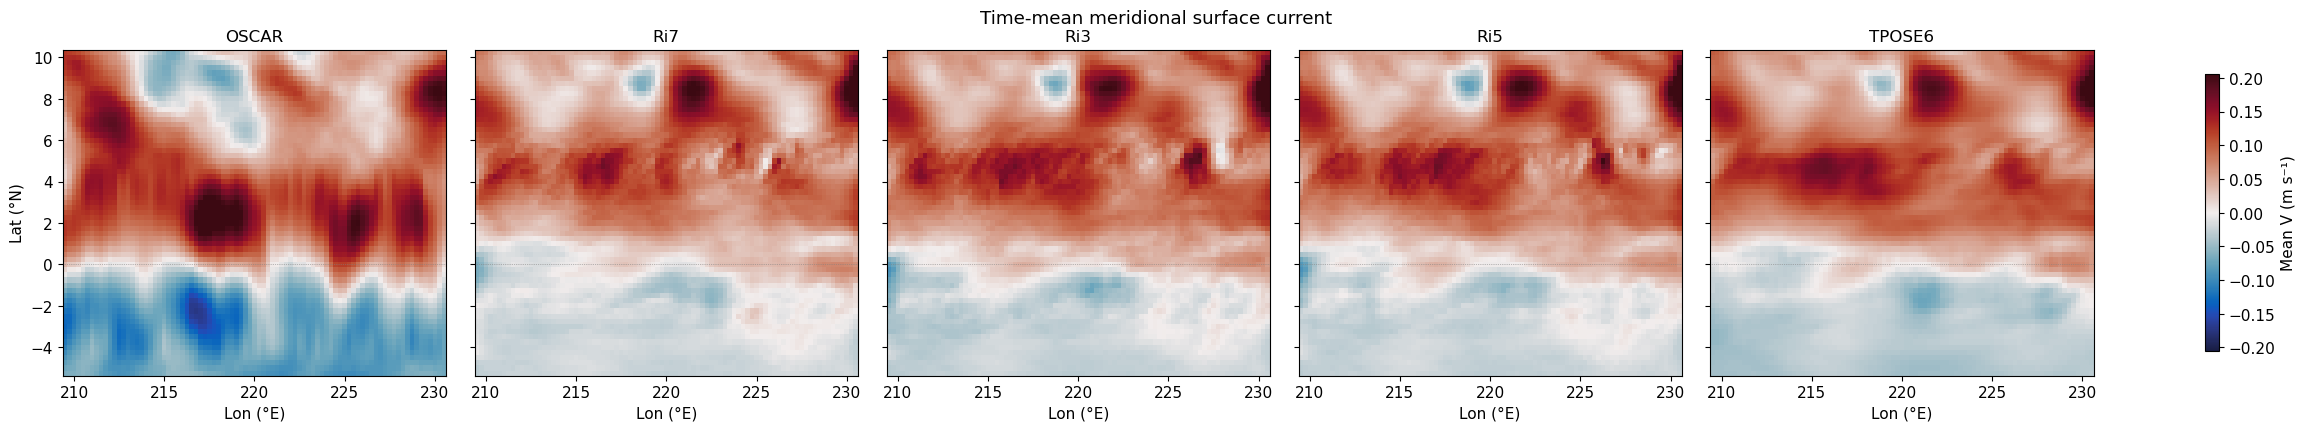

In [9]:
# ── 2-D: time-mean meridional current V (OSCAR + each model) ─────────
n = len(MODELS) + 1
allv = [obs_v_mean] + [results[l]['v_mean'] for l, _ in MODELS]
vmax = np.nanmax([np.nanpercentile(np.abs(a), 99) for a in allv])
fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4), sharex=True,
                         sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
im = axes[0].pcolormesh(lon, lat, obs_v_mean, cmap=cmo.balance,
                        vmin=-vmax, vmax=vmax, shading='auto')
axes[0].set_title('OSCAR')
for i, (label, _) in enumerate(MODELS):
    axes[i + 1].pcolormesh(lon, lat, results[label]['v_mean'],
                           cmap=cmo.balance, vmin=-vmax, vmax=vmax,
                           shading='auto')
    axes[i + 1].set_title(label)
for ax in axes:
    ax.axhline(0, color='gray', lw=0.5, ls=':'); ax.set_xlabel('Lon (°E)')
axes[0].set_ylabel('Lat (°N)')
fig.colorbar(im, ax=axes, label='Mean V (m s⁻¹)', shrink=0.85)
fig.suptitle('Time-mean meridional surface current', y=1.04)
fig.savefig(f'{OUTDIR}/oscar_2d_mean_V.png', dpi=150, bbox_inches='tight')
plt.show()


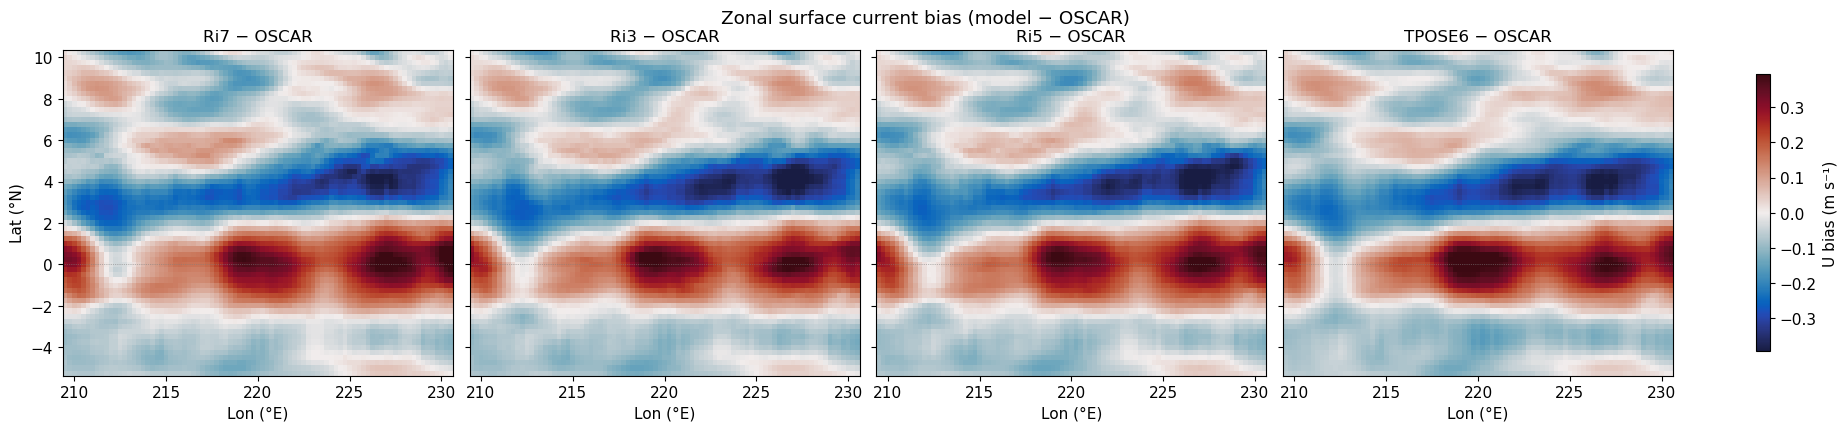

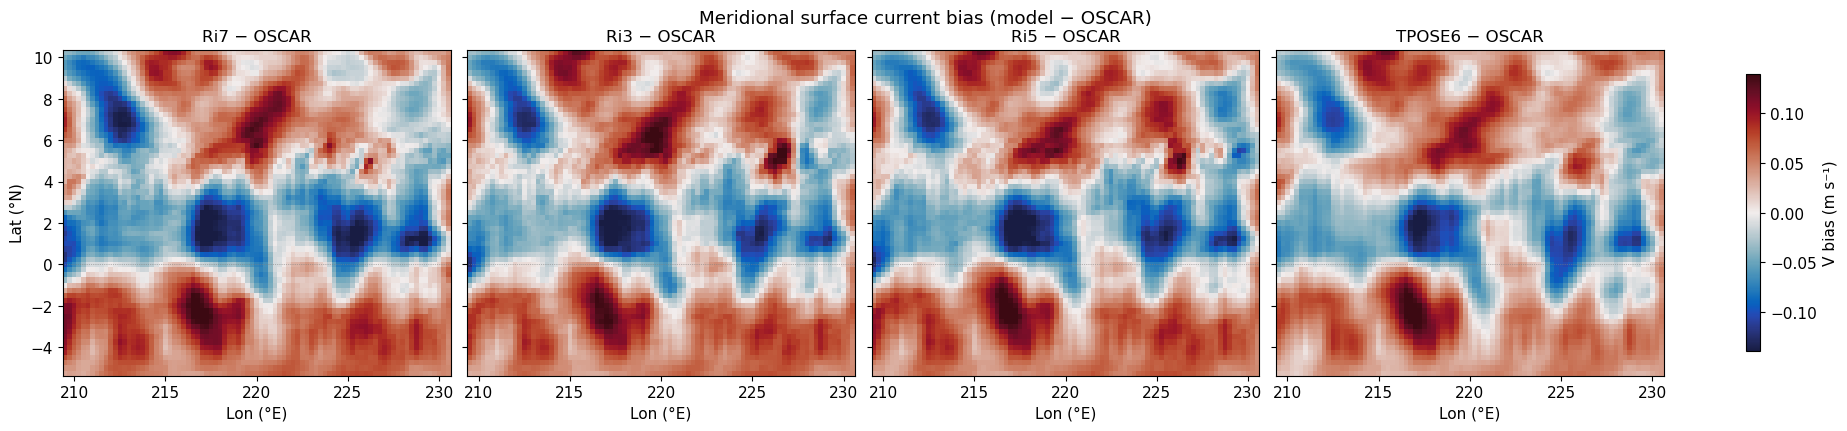

In [10]:
# ── 2-D: U and V bias maps (model − OSCAR) ───────────────────────────
for comp, key, title in [('U', 'u_bias', 'Zonal'),
                         ('V', 'v_bias', 'Meridional')]:
    n = len(MODELS)
    vmax = np.nanmax([np.nanpercentile(np.abs(results[l][key]), 99)
                      for l, _ in MODELS])
    fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4), sharex=True,
                             sharey=True, constrained_layout=True)
    axes = np.atleast_1d(axes)
    for i, (label, _) in enumerate(MODELS):
        im = axes[i].pcolormesh(lon, lat, results[label][key],
                                cmap=cmo.balance, vmin=-vmax, vmax=vmax,
                                shading='auto')
        axes[i].set_title(f'{label} − OSCAR')
        axes[i].axhline(0, color='gray', lw=0.5, ls=':')
        axes[i].set_xlabel('Lon (°E)')
    axes[0].set_ylabel('Lat (°N)')
    fig.colorbar(im, ax=axes, label=f'{comp} bias (m s⁻¹)', shrink=0.85)
    fig.suptitle(f'{title} surface current bias (model − OSCAR)', y=1.04)
    fig.savefig(f'{OUTDIR}/oscar_2d_{comp.lower()}_bias_maps.png', dpi=150,
                bbox_inches='tight')
    plt.show()
